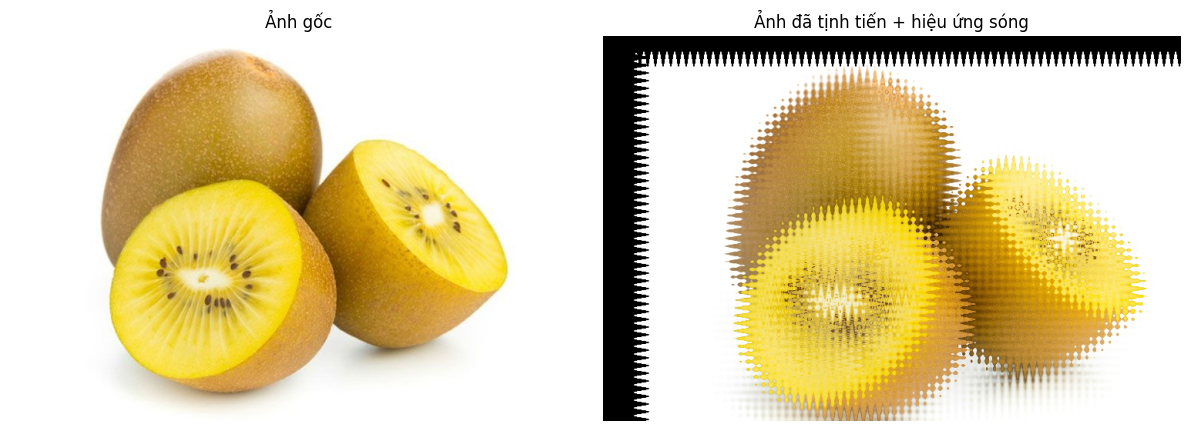

In [ ]:
from PIL import Image
import numpy as np
from scipy.ndimage import map_coordinates
import matplotlib.pyplot as plt

# Đọc ảnh
img = Image.open("kiwi.jpg").convert("RGB")
img_np = np.array(img)
h, w, c = img_np.shape

# Tịnh tiến ảnh
x_shift, y_shift = 50, 30
shifted_img = np.zeros_like(img_np)
shifted_img[y_shift:, x_shift:] = img_np[:h - y_shift, :w - x_shift]

# Tạo hiệu ứng sóng
X, Y = np.meshgrid(np.arange(w), np.arange(h))
amplitude = 10
frequency = 0.1
X_new = X + amplitude * np.sin(2 * np.pi * Y * frequency)
Y_new = Y + amplitude * np.sin(2 * np.pi * X * frequency)
X_new = np.clip(X_new, 0, w - 1)
Y_new = np.clip(Y_new, 0, h - 1)

# Biến đổi ảnh theo tọa độ mới
wave_img = np.zeros_like(shifted_img)
for i in range(c):
    wave_img[..., i] = map_coordinates(shifted_img[..., i], [Y_new, X_new], order=1, mode='reflect')

# Lưu ảnh kết quả
Image.fromarray(wave_img).save("kiwi_wave.jpg")

# Hiển thị ảnh trước và sau
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_np)
plt.title("Ảnh gốc")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(wave_img)
plt.title("Ảnh đã tịnh tiến + hiệu ứng sóng")
plt.axis("off")

plt.tight_layout()
plt.show()


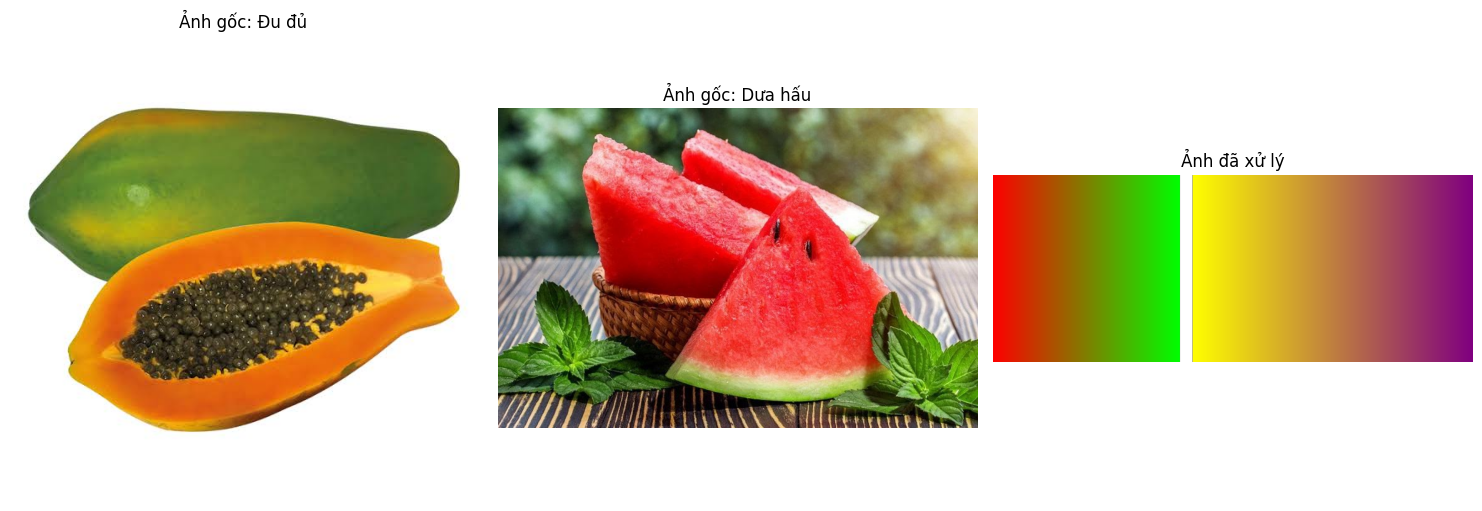

In [3]:
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt


# Bước 1: Đọc ảnh PNG (đã có alpha channel)
papaya = Image.open("dd.jpg").convert("RGBA")
watermelon = Image.open("dua_hau.jpg").convert("RGBA")

# Bước 2: Resize ảnh về cùng chiều cao
common_height = 300
papaya = ImageOps.contain(papaya, (1000, common_height))
watermelon = ImageOps.contain(watermelon, (1000, common_height))

# Bước 3: Chuyển ảnh sang NumPy để xử lý màu
pp_np = np.array(papaya)
wm_np = np.array(watermelon)

# Bước 4: Hàm tạo gradient màu
def apply_gradient_color(image_np, color_start, color_end):
    h, w, _ = image_np.shape
    gradient = np.linspace(0, 1, w).reshape(1, w, 1)
    gradient = np.repeat(gradient, h, axis=0)
    start_rgb = np.array(color_start).reshape(1, 1, 3)
    end_rgb = np.array(color_end).reshape(1, 1, 3)
    gradient_rgb = (start_rgb + (end_rgb - start_rgb) * gradient).astype(np.uint8)
    alpha_channel = image_np[..., 3:]
    result = np.concatenate((gradient_rgb, alpha_channel), axis=2)
    return result

# Bước 5: Áp dụng gradient màu
pp_gradient = apply_gradient_color(pp_np, (255, 0, 0), (0, 255, 0))       # Đỏ → Xanh lá
wm_gradient = apply_gradient_color(wm_np, (255, 255, 0), (128, 0, 128))  # Vàng → Tím

# Bước 6: Chuyển lại ảnh từ NumPy về PIL
pp_img = Image.fromarray(pp_gradient, "RGBA")
wm_img = Image.fromarray(wm_gradient, "RGBA")

# Bước 7: Tạo nền trong suốt và ghép 2 ảnh
canvas_width = pp_img.width + wm_img.width + 20
canvas_height = max(pp_img.height, wm_img.height)
background = Image.new("RGBA", (canvas_width, canvas_height), (0, 0, 0, 0))
background.paste(pp_img, (0, 0), pp_img)
background.paste(wm_img, (pp_img.width + 20, 0), wm_img)

# Bước 8: Lưu ảnh kết quả
output_file = "fruit_combo.png"
background.save(output_file)

# Đọc ảnh gốc và ảnh kết quả
papaya_img = Image.open("dd.jpg").convert("RGBA")
watermelon_img = Image.open("dua_hau.jpg").convert("RGBA")
result_img = Image.open("fruit_combo.png")

# Hiển thị ảnh
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(papaya_img)
plt.title("Ảnh gốc: Đu đủ")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(watermelon_img)
plt.title("Ảnh gốc: Dưa hấu")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(result_img)
plt.title("Ảnh đã xử lý")
plt.axis("off")

plt.tight_layout()
plt.show()


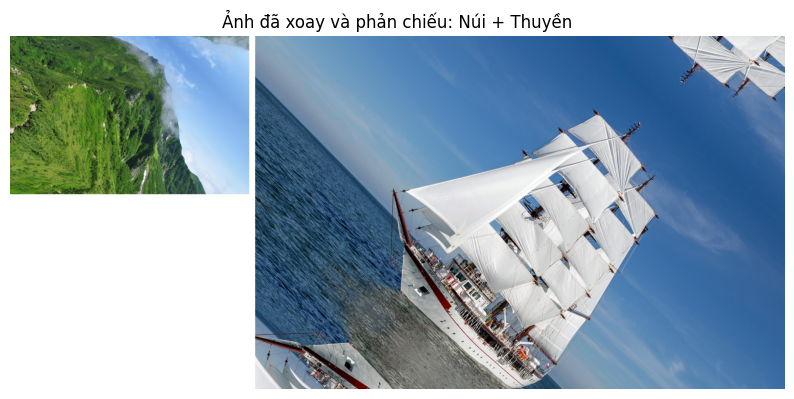

In [4]:
from PIL import Image, ImageOps
from scipy.ndimage import rotate
import numpy as np

# Bước 1: Đọc ảnh gốc
img_boat = Image.open("thuyen.jpg").convert("RGB")
img_mountain = Image.open("nui.jpg").convert("RGB")

# Bước 2: Chuyển sang mảng NumPy và xoay 45 độ (reshape=False để giữ kích thước)
boat_np = np.array(img_boat)
mountain_np = np.array(img_mountain)

rotated_boat = rotate(boat_np, angle=45, reshape=False, order=1, mode='reflect')
rotated_mountain = rotate(mountain_np, angle=45, reshape=False, order=1, mode='reflect')

# Bước 3: Chuyển lại sang ảnh và tạo phản chiếu dọc (vertical mirror)
rotated_boat_img = Image.fromarray(rotated_boat.astype(np.uint8))
rotated_mountain_img = Image.fromarray(rotated_mountain.astype(np.uint8))

boat_mirrored = ImageOps.mirror(rotated_boat_img)
mountain_mirrored = ImageOps.mirror(rotated_mountain_img)

# Bước 4: Tạo canvas trắng và ghép hai ảnh
canvas_width = boat_mirrored.width + mountain_mirrored.width + 20
canvas_height = max(boat_mirrored.height, mountain_mirrored.height)
canvas = Image.new("RGB", (canvas_width, canvas_height), (255, 255, 255))  # nền trắng

canvas.paste(mountain_mirrored, (0, 0))
canvas.paste(boat_mirrored, (mountain_mirrored.width + 20, 0))

# Bước 5: Lưu ảnh kết quả
canvas.save("mountain_boat_mirror.jpg")

# Đọc ảnh kết quả
result = Image.open("mountain_boat_mirror.jpg")

# Hiển thị
plt.figure(figsize=(10, 6))
plt.imshow(result)
plt.title("Ảnh đã xoay và phản chiếu: Núi + Thuyền")
plt.axis("off")
plt.show()

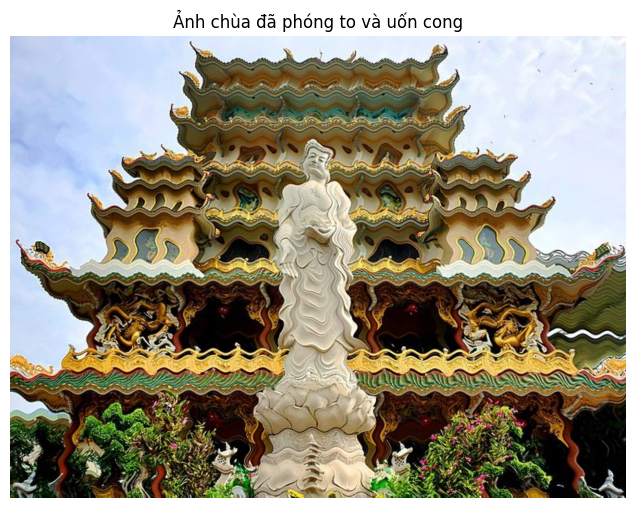

In [ ]:
from PIL import Image
import numpy as np
from scipy.ndimage import map_coordinates
import matplotlib.pyplot as plt

# Bước 1: Đọc ảnh chùa và phóng to 5 lần
img = Image.open("chua.jpg").convert("RGB")
w, h = img.size
img_resized = img.resize((w * 5, h * 5), Image.LANCZOS)

# Bước 2: Chuyển ảnh sang NumPy
img_np = np.array(img_resized)
h, w, c = img_np.shape

# Bước 3: Tạo lưới tọa độ và hiệu ứng uốn cong (sử dụng sin)
Y, X = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')

# Uốn cong theo chiều ngang và dọc bằng hàm sin
amplitude = 20
freq = 2 * np.pi / 200
X_warped = X + amplitude * np.sin(Y * freq)
Y_warped = Y + amplitude * np.sin(X * freq)

# Đảm bảo không ra ngoài ảnh
X_warped = np.clip(X_warped, 0, w - 1)
Y_warped = np.clip(Y_warped, 0, h - 1)

# Bước 4: Nội suy để lấy pixel tại vị trí mới
warped_img = np.zeros_like(img_np)
for i in range(3):  # RGB
    warped_img[..., i] = map_coordinates(img_np[..., i], [Y_warped, X_warped], order=1, mode='reflect')

# Bước 5: Lưu kết quả
Image.fromarray(warped_img).save("pagoda_warped.jpg")

# Bước 6: Hiển thị ảnh
plt.figure(figsize=(10, 6))
plt.imshow(warped_img)
plt.title("Ảnh chùa đã phóng to và uốn cong")
plt.axis("off")
plt.show()


=== CHỌN ẢNH ===
1: chua.jpg
2: nui.jpg
3: thuyen.jpg

=== MENU BIẾN ĐỔI HÌNH ẢNH ===
1. Tịnh tiến
2. Xoay ảnh
3. Phóng to / Thu nhỏ
4. Làm mờ Gaussian
5. Biến dạng sóng


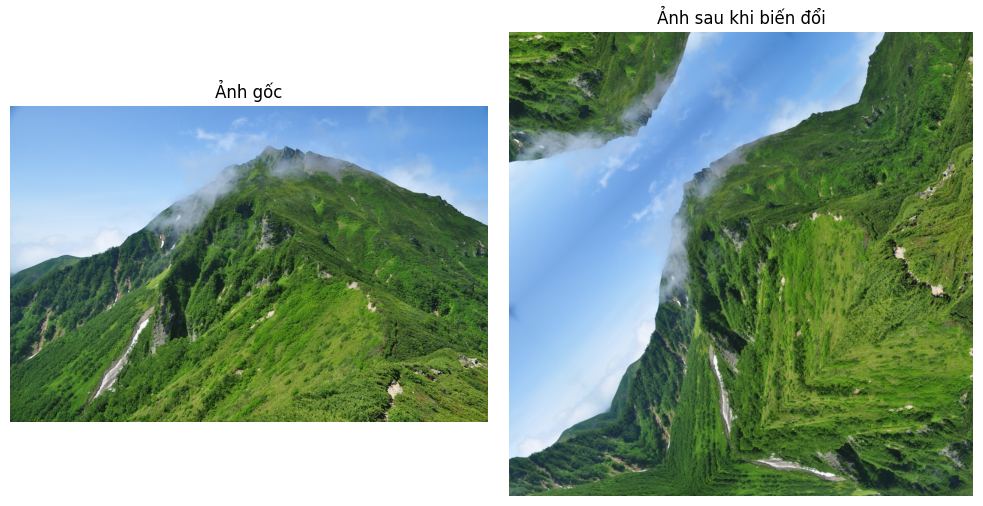

✅ Ảnh đã được lưu thành 'image_transformed.jpg'


In [4]:
import numpy as np
from PIL import Image
from scipy.ndimage import shift, rotate, zoom, gaussian_filter, map_coordinates
import matplotlib.pyplot as plt

# --- BƯỚC 1: CHỌN ẢNH ---
def choose_image():
    images = {
        "1": "chua.jpg",
        "2": "nui.jpg",
        "3": "thuyen.jpg"
    }
    print("=== CHỌN ẢNH ===")
    for k, v in images.items():
        print(f"{k}: {v}")
    choice = input("Nhập số tương ứng (1-3): ")
    return images.get(choice, "chua.jpg")

# --- BƯỚC 2: MENU BIẾN ĐỔI ---
def show_menu():
    print("\n=== MENU BIẾN ĐỔI HÌNH ẢNH ===")
    print("1. Tịnh tiến")
    print("2. Xoay ảnh")
    print("3. Phóng to / Thu nhỏ")
    print("4. Làm mờ Gaussian")
    print("5. Biến dạng sóng")
    return input("Chọn phép biến đổi (1-5): ")

# --- CÁC PHÉP BIẾN ĐỔI ---
def apply_translation(img_np):
    dx = int(input("Nhập số pixel tịnh tiến theo X: "))
    dy = int(input("Nhập số pixel tịnh tiến theo Y: "))
    return shift(img_np, shift=(dy, dx, 0), mode='reflect')

def apply_rotation(img_np):
    angle = float(input("Nhập góc xoay (độ): "))
    reshape_opt = input("Giữ kích thước cũ? (y/n): ").strip().lower() != 'n'
    return rotate(img_np, angle=angle, reshape=reshape_opt, order=1, mode='reflect')

def apply_zoom(img_np):
    factor = float(input("Nhập hệ số zoom (ví dụ: 0.5 thu nhỏ, 2 phóng to): "))
    return zoom(img_np, zoom=(factor, factor, 1), order=1)

def apply_blur(img_np):
    sigma = float(input("Nhập độ mờ (sigma): "))
    return gaussian_filter(img_np, sigma=(sigma, sigma, 0))

def apply_wave(img_np):
    h, w, _ = img_np.shape
    Y, X = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
    amp = float(input("Nhập biên độ sóng (amplitude): "))
    freq = 2 * np.pi / 150
    X_new = X + amp * np.sin(Y * freq)
    Y_new = Y + amp * np.sin(X * freq)
    X_new = np.clip(X_new, 0, w - 1)
    Y_new = np.clip(Y_new, 0, h - 1)
    result = np.zeros_like(img_np)
    for i in range(3):
        result[..., i] = map_coordinates(img_np[..., i], [Y_new, X_new], order=1, mode='reflect')
    return result

# --- CHƯƠNG TRÌNH CHÍNH ---
def main():
    img_path = choose_image()
    img = Image.open(img_path).convert("RGB")
    img_np = np.array(img)

    operation = show_menu()

    if operation == "1":
        result = apply_translation(img_np)
    elif operation == "2":
        result = apply_rotation(img_np)
    elif operation == "3":
        result = apply_zoom(img_np)
    elif operation == "4":
        result = apply_blur(img_np)
    elif operation == "5":
        result = apply_wave(img_np)
    else:
        print("Lựa chọn không hợp lệ.")
        return

    # Hiển thị kết quả
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Ảnh gốc")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(np.clip(result, 0, 255).astype(np.uint8))
    plt.title("Ảnh sau khi biến đổi")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Lưu ảnh kết quả
    Image.fromarray(np.clip(result, 0, 255).astype(np.uint8)).save("image_transformed.jpg")
    print("✅ Ảnh đã được lưu thành 'image_transformed.jpg'")

# Chạy chương trình
if __name__ == "__main__":
    main()
